# All Symbols Correlation Analysis

This notebook fetches all active symbols from the Binbot API, retrieves candlestick data from Binance for each symbol, and computes a correlation matrix among all assets. The correlation matrix is visualized as a heatmap for easy analysis.

In [5]:
%pip install -q ipywidgets seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
# Import Required Libraries
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

## Fetch All Active Symbols from API

We will use the Binbot API to get all active trading symbols.

In [7]:
# Fetch all active symbols from the API
symbols_url = "https://api.terminal.binbot.in/symbols"
symbols_resp = requests.get(symbols_url)
symbols_data = symbols_resp.json()["data"]
active_symbols = [s["id"] for s in symbols_data if s.get("active")]
print(f"Found {len(active_symbols)} active symbols.")
# Optionally, preview a few symbols
print("Sample symbols:", active_symbols[:10])

Found 428 active symbols.
Sample symbols: ['ETHBTC', 'LTCBTC', 'BNBBTC', 'NEOBTC', 'GASBTC', 'LRCBTC', 'QTUMBTC', 'ZRXBTC', 'KNCBTC', 'IOTABTC']


## Fetch Candlestick Data for Each Symbol

We will fetch recent 15m candlestick close prices for each active symbol from Binance.

In [8]:
# Fetch candlestick close prices for each symbol from Binance
from tqdm.notebook import tqdm
import time

def fetch_binance_closes(symbol, interval="15m", limit=200):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    resp = requests.get(url, params=params)
    if resp.status_code != 200:
        return None
    data = resp.json()
    if not data:
        return None
    df = pd.DataFrame(data, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "qav", "num_trades", "taker_base", "taker_quote", "ignore"
    ])
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close"] = df["close"].astype(float)
    return df[["timestamp", "close"]]

closes_dict = {}
for symbol in tqdm(active_symbols, desc="Fetching candlesticks"):
    try:
        df = fetch_binance_closes(symbol)
        if df is not None and len(df) > 0:
            closes_dict[symbol] = df.set_index("timestamp")["close"]
        time.sleep(0.1)  # Be nice to the API
    except Exception as e:
        print(f"Failed for {symbol}: {e}")

print(f"Fetched data for {len(closes_dict)} symbols.")

Fetching candlesticks:   0%|          | 0/428 [00:00<?, ?it/s]

Fetched data for 428 symbols.


## Combine Closing Prices into a Single DataFrame

We will align all symbols' close prices by timestamp and combine them into a single DataFrame.

In [9]:
# Combine all close price series into a single DataFrame
if closes_dict:
    df_closes = pd.DataFrame(closes_dict)
    print(f"Combined DataFrame shape: {df_closes.shape}")
    display(df_closes.tail())
else:
    print("No close price data available.")

Combined DataFrame shape: (200, 428)


,ETHBTC,LTCBTC,BNBBTC,NEOBTC,GASBTC,LRCBTC,QTUMBTC,ZRXBTC,KNCBTC,IOTABTC,...,PROVEUSDC,ILVUSDC,MAGICUSDC,PLUMEUSDC,CYBERUSDC,MAVUSDC,SKLUSDC,A2ZUSDC,SSVUSDC,UMAUSDC
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-08-27 14:30:00,0.04136,0.001020,0.007705,0.000064,0.000031,8.000000e-07,0.000026,0.000002,0.000003,0.000002,...,1.0736,14.76,0.2113,0.08462,2.025,0.06164,0.02831,0.005372,9.03,1.395
2025-08-27 14:45:00,0.04126,0.001016,0.007713,0.000064,0.000030,8.000000e-07,0.000026,0.000002,0.000003,0.000002,...,1.0750,14.65,0.2112,0.08442,2.016,0.06120,0.02816,0.005372,9.03,1.398
2025-08-27 15:00:00,0.04143,0.001019,0.007722,0.000064,0.000030,8.000000e-07,0.000025,0.000002,0.000003,0.000002,...,1.0857,14.73,0.2095,0.08452,2.021,0.06087,0.02816,0.005372,9.03,1.393
2025-08-27 15:15:00,0.04150,0.001016,0.007731,0.000064,0.000030,8.000000e-07,0.000025,0.000002,0.000003,0.000002,...,1.0871,14.71,0.2091,0.08482,2.017,0.06083,0.02797,0.005283,9.03,1.393
2025-08-27 15:30:00,0.04150,0.001017,0.007726,0.000064,0.000031,8.000000e-07,0.000025,0.000002,0.000003,0.000002,...,1.0778,14.73,0.2086,0.08522,2.017,0.06064,0.02814,0.005279,9.03,1.392


## Compute Correlation Matrix

We will calculate the correlation matrix for the closing prices of all symbols.

In [10]:
# Compute the correlation matrix for the closing prices
if 'df_closes' in locals() and not df_closes.empty:
    corr_matrix = df_closes.corr()
    print(f"Correlation matrix shape: {corr_matrix.shape}")
    display(corr_matrix)
else:
    print("No closing price data to compute correlation matrix.")

Correlation matrix shape: (428, 428)


,ETHBTC,LTCBTC,BNBBTC,NEOBTC,GASBTC,LRCBTC,QTUMBTC,ZRXBTC,KNCBTC,IOTABTC,...,PROVEUSDC,ILVUSDC,MAGICUSDC,PLUMEUSDC,CYBERUSDC,MAVUSDC,SKLUSDC,A2ZUSDC,SSVUSDC,UMAUSDC
ETHBTC,1.000000,0.767320,0.814927,-0.155415,-0.096216,0.853741,-0.305016,0.945872,0.935038,0.831683,...,0.644559,0.856875,0.531104,0.185492,0.307499,-0.201953,-0.076426,-0.408420,0.694438,0.692775
LTCBTC,0.767320,1.000000,0.703445,-0.582171,-0.485697,0.731837,-0.370805,0.838114,0.820819,0.781309,...,0.474927,0.824170,0.540209,-0.096409,0.236061,-0.378705,-0.368346,0.042169,0.289287,0.722859
BNBBTC,0.814927,0.703445,1.000000,-0.112785,-0.054350,0.682050,-0.055948,0.806569,0.833709,0.742826,...,0.454496,0.769769,0.674876,0.124515,0.117721,-0.173737,-0.019053,-0.116193,0.362436,0.802159
NEOBTC,-0.155415,-0.582171,-0.112785,1.000000,0.864283,-0.390409,0.684450,-0.360823,-0.176583,-0.264680,...,-0.040562,-0.315389,0.087065,0.455102,-0.040349,0.538266,0.719286,0.368793,-0.012888,-0.225035
GASBTC,-0.096216,-0.485697,-0.054350,0.864283,1.000000,-0.390373,0.608521,-0.315540,-0.079427,-0.102092,...,-0.119898,-0.271080,0.086044,0.607967,0.009890,0.400390,0.762676,0.482844,-0.193905,-0.135866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MAVUSDC,-0.201953,-0.378705,-0.173737,0.538266,0.400390,-0.407687,0.591027,-0.347679,-0.132846,-0.188872,...,-0.056050,-0.072253,0.187644,0.400181,0.070235,1.000000,0.665595,0.725921,-0.254654,0.080525
SKLUSDC,-0.076426,-0.368346,-0.019053,0.719286,0.762676,-0.382361,0.661488,-0.287575,0.015850,0.005312,...,-0.107941,-0.041173,0.297876,0.734528,0.195067,0.665595,1.000000,0.737106,-0.401069,0.108023
A2ZUSDC,-0.408420,0.042169,-0.116193,0.368793,0.482844,-0.616794,0.738553,-0.537293,-0.046392,0.009289,...,-0.047241,0.163578,0.463487,0.599587,0.453925,0.725921,0.737106,1.000000,-0.537637,-0.105872
SSVUSDC,0.694438,0.289287,0.362436,-0.012888,-0.193905,0.681880,-0.389899,0.694473,0.417095,0.482352,...,0.516491,0.407122,-0.027984,-0.177968,-0.442001,-0.254654,-0.401069,-0.537637,1.000000,0.292963


## Visualize Correlation Matrix

We will plot a heatmap of the correlation matrix for visual analysis.

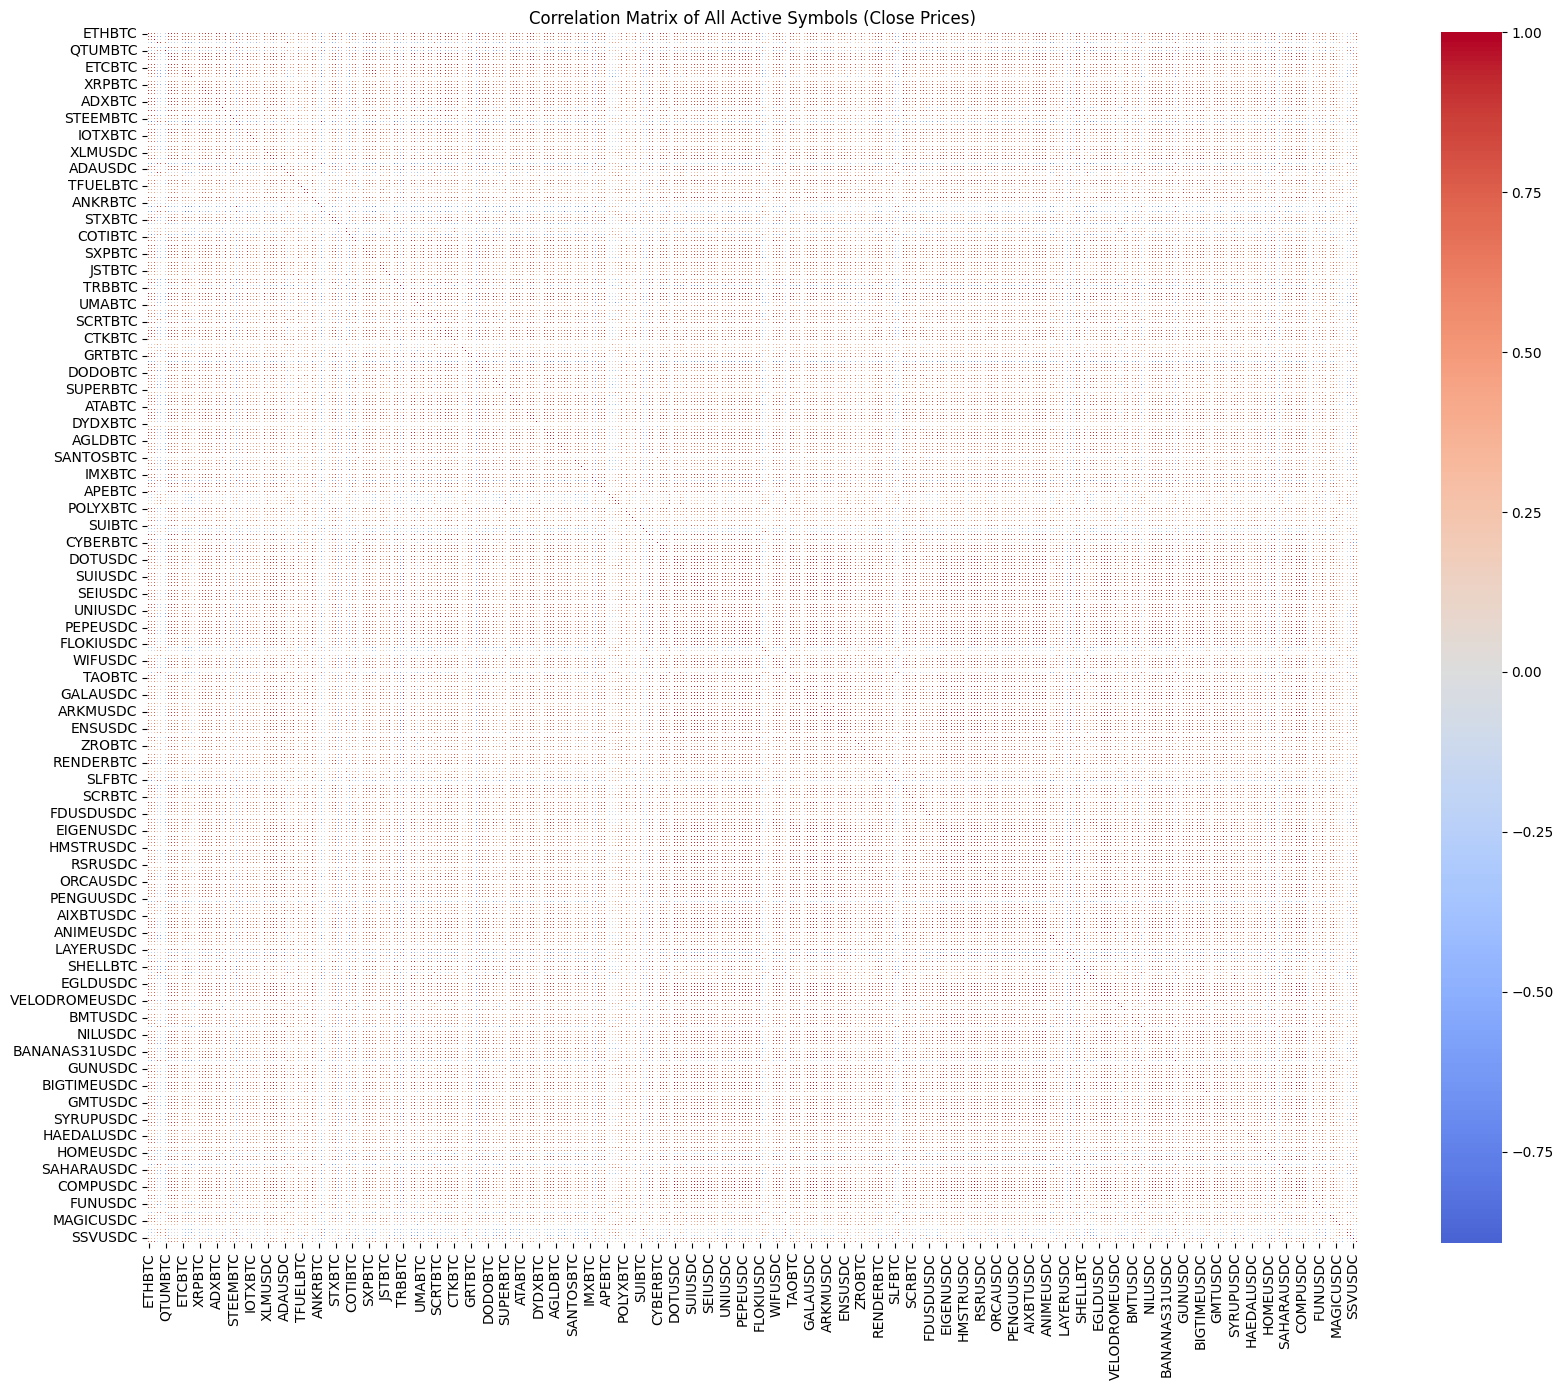

In [11]:
# Plot a heatmap of the correlation matrix
if 'corr_matrix' in locals() and not corr_matrix.empty:
    plt.figure(figsize=(18, 14))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, linewidths=0.1)
    plt.title('Correlation Matrix of All Active Symbols (Close Prices)')
    plt.tight_layout()
    plt.show()
else:
    print("No correlation matrix to plot.")

## Group Assets by Correlation Sign and Visualize

Instead of a heatmap, we will group asset pairs by positive and negative correlations and visualize them in a scatterplot. Each point will represent a pair of assets, with the x-axis as one asset, y-axis as the other, and color indicating positive or negative correlation.

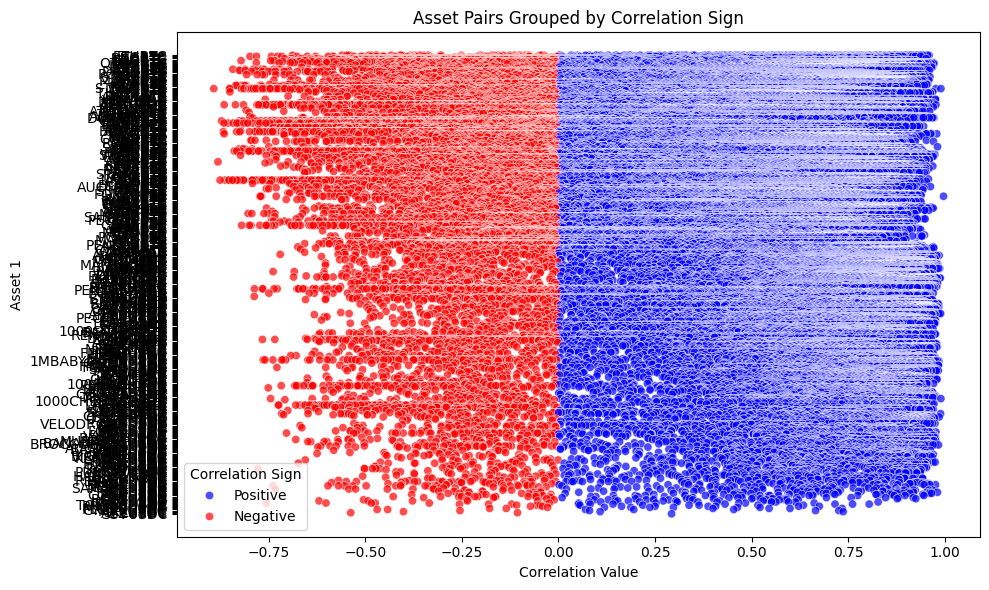

In [12]:
# Group asset pairs by correlation sign and plot as scatterplot
if 'corr_matrix' in locals() and not corr_matrix.empty:
    corr_pairs = corr_matrix.stack().reset_index()
    corr_pairs.columns = ['Asset1', 'Asset2', 'Correlation']
    # Remove self-correlations
    corr_pairs = corr_pairs[corr_pairs['Asset1'] != corr_pairs['Asset2']]
    # Drop duplicate pairs (A,B) and (B,A)
    corr_pairs['pair'] = corr_pairs.apply(lambda x: tuple(sorted([x['Asset1'], x['Asset2']])), axis=1)
    corr_pairs = corr_pairs.drop_duplicates('pair')
    # Group by sign
    corr_pairs['Sign'] = np.where(corr_pairs['Correlation'] < 0, 'Negative', 'Positive')
    # Scatterplot: x=Correlation, y=Asset1, color=Sign
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=corr_pairs,
        x='Correlation',
        y='Asset1',
        hue='Sign',
        palette={'Positive': 'blue', 'Negative': 'red'},
        alpha=0.7
    )
    plt.title('Asset Pairs Grouped by Correlation Sign')
    plt.xlabel('Correlation Value')
    plt.ylabel('Asset 1')
    plt.legend(title='Correlation Sign')
    plt.tight_layout()
    plt.show()
else:
    print("No correlation matrix to plot.")

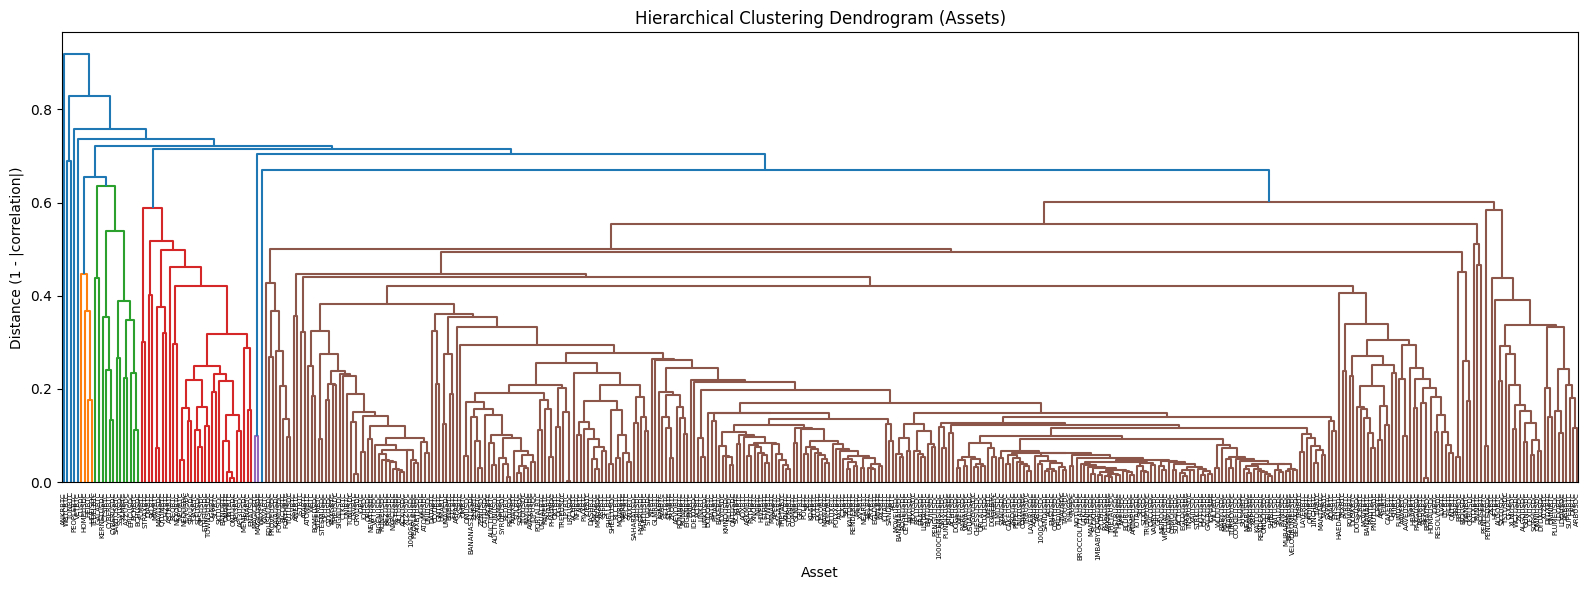

Cluster assignments (asset: cluster):
{'ETHBTC': np.int32(2), 'LTCBTC': np.int32(2), 'BNBBTC': np.int32(2), 'NEOBTC': np.int32(2), 'GASBTC': np.int32(2), 'LRCBTC': np.int32(2), 'QTUMBTC': np.int32(2), 'ZRXBTC': np.int32(2), 'KNCBTC': np.int32(2), 'IOTABTC': np.int32(2), 'LINKBTC': np.int32(2), 'MTLBTC': np.int32(2), 'ETCBTC': np.int32(2), 'ZECBTC': np.int32(2), 'DASHBTC': np.int32(2), 'REQBTC': np.int32(2), 'TRXBTC': np.int32(2), 'POWRBTC': np.int32(2), 'XRPBTC': np.int32(2), 'ENJBTC': np.int32(2), 'STORJBTC': np.int32(2), 'BATBTC': np.int32(2), 'LSKBTC': np.int32(2), 'MANABTC': np.int32(2), 'ADXBTC': np.int32(2), 'ADABTC': np.int32(2), 'XLMBTC': np.int32(2), 'ICXBTC': np.int32(2), 'RLCBTC': np.int32(2), 'PIVXBTC': np.int32(2), 'STEEMBTC': np.int32(2), 'ONTBTC': np.int32(2), 'WANBTC': np.int32(2), 'SYSBTC': np.int32(2), 'ZENBTC': np.int32(2), 'THETABTC': np.int32(2), 'IOTXBTC': np.int32(2), 'DATABTC': np.int32(2), 'ARDRBTC': np.int32(2), 'VETBTC': np.int32(3), 'RVNBTC': np.int32(2), 'X

In [13]:
# Hierarchical clustering of assets based on correlation
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

if 'corr_matrix' in locals() and not corr_matrix.empty:
    # Fill NaN in correlation matrix with 0 (treat as no correlation)
    corr_filled = corr_matrix.fillna(0)
    # Convert correlation to distance
    distance_matrix = 1 - corr_filled.abs()
    # Set diagonal to 0 (distance to self)
    np.fill_diagonal(distance_matrix.values, 0)
    # Check if the matrix is square and non-empty
    if not distance_matrix.empty and distance_matrix.shape[0] == distance_matrix.shape[1]:
        # Convert to condensed distance matrix for linkage
        condensed_dist = squareform(distance_matrix.values, checks=False)
        # Perform hierarchical clustering
        Z = linkage(condensed_dist, method='average')
        # Plot dendrogram
        plt.figure(figsize=(16, 6))
        dendrogram(Z, labels=distance_matrix.columns, leaf_rotation=90)
        plt.title('Hierarchical Clustering Dendrogram (Assets)')
        plt.xlabel('Asset')
        plt.ylabel('Distance (1 - |correlation|)')
        plt.tight_layout()
        plt.show()
        # Optionally, assign cluster labels (e.g., 5 clusters)
        cluster_labels = fcluster(Z, t=5, criterion='maxclust')
        asset_clusters = dict(zip(distance_matrix.columns, cluster_labels))
        print('Cluster assignments (asset: cluster):')
        print(asset_clusters)
    else:
        print('No sufficient data for clustering (distance matrix is empty or not square).')
else:
    print('No correlation matrix to cluster.')

In [14]:
# Assign clusters using a distance threshold of 0.4 and print the results
from scipy.cluster.hierarchy import fcluster
from collections import defaultdict

if 'Z' in locals():
    cluster_labels_04 = fcluster(Z, t=0.30, criterion='distance')
    asset_clusters_04 = dict(zip(distance_matrix.columns, cluster_labels_04))
    unique_clusters_04 = set(cluster_labels_04)
    print(f"Number of clusters at distance threshold 0.4: {len(unique_clusters_04)}")
    print(f"Cluster labels: {sorted(unique_clusters_04)}")
    # Optionally, show a few assets per cluster
    clusters_dict = defaultdict(list)
    for symbol, label in asset_clusters_04.items():
        clusters_dict[label].append(symbol)
    for label, symbols in clusters_dict.items():
        print(f"Cluster {label}: {symbols[:5]}{'...' if len(symbols) > 5 else ''}")
else:
    print('No linkage matrix Z found. Run the clustering cell first.')

Number of clusters at distance threshold 0.4: 57
Cluster labels: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31), np.int32(32), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), np.int32(39), np.int32(40), np.int32(41), np.int32(42), np.int32(43), np.int32(44), np.int32(45), np.int32(46), np.int32(47), np.int32(48), np.int32(49), np.int32(50), np.int32(51), np.int32(52), np.int32(53), np.int32(54), np.int32(55), np.int32(56), np.int32(57)]
Cluster 37: ['ETHBTC', 'LRCBTC', 'ZRXBTC', 'KNCBTC', 'IOTABTC']...
Cluster 41: ['LTCBTC', 'ARDRBTC', 'HBARBTC', 'AAVEBTC', 'FILBTC']...
Cluster 3

In [15]:
# KMeans clustering on PCA-reduced correlation data
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np
from collections import defaultdict, Counter

# Use the absolute correlation matrix as features
if 'corr_matrix' in locals() and not corr_matrix.empty:
    corr_features = corr_matrix.abs().fillna(0)
    # Optionally, reduce dimensionality for clustering
    pca = PCA(n_components=min(10, corr_features.shape[1]))
    features_pca = pca.fit_transform(corr_features)
    # Choose number of clusters (e.g., 5, or use elbow method)
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(features_pca)
    asset_kmeans_clusters = dict(zip(corr_features.index, kmeans_labels))
    clusters_dict = defaultdict(list)
    for symbol, label in asset_kmeans_clusters.items():
        clusters_dict[label].append(symbol)
    print(f'Number of clusters: {len(clusters_dict)}')
    # Collect a Counter for each cluster, counting each asset_index name only once per symbol
    cluster_counters = {}
    symbols_resp = requests.get(f"http://localhost:8008/symbols?symbol={symbol}")
    symbols_data = symbols_resp.json()["data"]
    for label, symbols in sorted(clusters_dict.items()):
        asset_index_counter = Counter()
        for symbol in symbols:
            try:
                unique_names = set()
                for asset in symbols_data:
                    if asset["id"] == symbol:
                        for indx in asset.get("asset_indices", []):
                            asset_index_counter[indx["name"]] += 1
                        continue
                            
                
            except Exception as e:
                print(f'Error fetching for symbol {symbol}: {e}')
            cluster_counters[label] = asset_index_counter

    for key, value in cluster_counters.items():
        print(f'Cluster {key}: {value}')

else:
    print('No correlation matrix available for KMeans clustering.')

Number of clusters: 5
Cluster 0: Counter()
Cluster 1: Counter()
Cluster 2: Counter()
Cluster 3: Counter()
Cluster 4: Counter()


In [16]:
# Assign asset index to each symbol in each cluster via PUT request
import requests

cluster_0_index = "meme"
cluster_1_index = "launchpool"
cluster_2_index = "infrastructure"
cluster_3_index = "hodler"
cluster_4_index = "layers"

# Define the mapping from cluster number to cluster index variable
cluster_indices = {
    0: cluster_0_index,
    1: cluster_1_index,
    2: cluster_2_index,
    3: cluster_3_index,
    4: cluster_4_index,
}

for cluster_num, symbols in clusters_dict.items():
    cluster_index = cluster_indices[cluster_num]
    for symbol in symbols:
        payload = {
            "id": symbol,
            "asset_indices": [
                {"id": cluster_index, "name": cluster_index.capitalize()}
            ],
        }
        
        try:
            response = requests.put(
                "https://api.terminal.binbot.in/symbol/asset-index", json=payload
            )
            print(
                f"PUT {symbol} to cluster {cluster_num} ({cluster_index}): {response.status_code}"
            )
        except Exception as e:
            print(f"Error for symbol {symbol}: {e}")


PUT ETHBTC to cluster 3 (hodler): 200
PUT KNCBTC to cluster 3 (hodler): 200
PUT IOTABTC to cluster 3 (hodler): 200
PUT LINKBTC to cluster 3 (hodler): 200
PUT MTLBTC to cluster 3 (hodler): 200
PUT ENJBTC to cluster 3 (hodler): 200
PUT STORJBTC to cluster 3 (hodler): 200
PUT LSKBTC to cluster 3 (hodler): 200
PUT ADABTC to cluster 3 (hodler): 200
PUT THETABTC to cluster 3 (hodler): 200
PUT XRPUSDC to cluster 3 (hodler): 200
PUT LINKUSDC to cluster 3 (hodler): 200
PUT LTCUSDC to cluster 3 (hodler): 200
PUT TRXUSDC to cluster 3 (hodler): 200
PUT FETBTC to cluster 3 (hodler): 200
PUT ADAUSDC to cluster 3 (hodler): 200
PUT ETCUSDC to cluster 3 (hodler): 200
PUT PHBBTC to cluster 3 (hodler): 200
PUT DOGEBTC to cluster 3 (hodler): 200
PUT DOGEUSDC to cluster 3 (hodler): 200
PUT HIVEBTC to cluster 3 (hodler): 200
PUT SXPBTC to cluster 3 (hodler): 200
PUT AVABTC to cluster 3 (hodler): 200
PUT SANDBTC to cluster 3 (hodler): 200
PUT TRBBTC to cluster 3 (hodler): 200
PUT SUSHIBTC to cluster 3 (hodle